# Pursuer — QR-DQN training pipeline

Trained model is written to `models/pursuer.onnx`;
Go loads it via the `ROGUE_PURSUER_MODEL_PATH` environment variable.

In [1]:
%pip install --upgrade pip 
%pip install --quiet 'gymnasium>=1.0' 'stable-baselines3>=2.4' sb3-contrib torch onnx onnxruntime tensorboard matplotlib tqdm rich ipywidgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Hyperparameters

In [ ]:
from pathlib import Path

CONFIG = {
    'topologies_dir':        'fixtures/topologies',
    'total_timesteps':       3_000_000,
    'n_envs':                8,
    'max_episode_steps':     40,
    'max_episode_steps_range': (30, 50),
    'seed':                  42,
    'model_out':             'models/pursuer.onnx',
    'checkpoint_dir':        'checkpoints',
    'tensorboard_log':       'runs',
    # --- Architecture ---
    'features_dim':          256,
    'n_quantiles':           51,
    # --- QR-DQN ---
    # Larger buffer-warmup + batch + exploration tuned for the richer 11-channel
    # observation and SE-attention path. Rationale: agent needs long-horizon
    # random exploration to discover covert-path / trail signal; larger batches
    # stabilise SE-block attention weights against 16-scalar variance.
    'buffer_size':           300_000,
    'learning_starts':       50_000,
    'batch_size':            512,
    'gamma':                 0.99,
    'learning_rate':         1e-4,
    'exploration_fraction':  0.50,
    'exploration_final_eps': 0.02,
    'train_freq':            4,
    'target_update_interval': 2_000,
    # --- Eval / metrics ---
    'eval_freq':             10_000,
    'eval_episodes':         20,
    'metrics_log_freq':      5_000,
    # --- Curriculum (4 stages: stone → dummy → default → randomized) ---
    # Tightened thresholds: require near-mastery on each stage before promoting,
    # so stone → training_dummy only after catch ≥0.85 (not 0.80) and
    # training_dummy → default only after catch ≥0.50 (not 0.30).
    'curriculum_check_freq':     10_000,
    'curriculum_stone_rew':      10.0,
    'curriculum_stone_catch':     0.85,
    'curriculum_dummy_rew':       8.0,
    'curriculum_dummy_catch':     0.50,
    'curriculum_default_rew':     6.0,
    'curriculum_default_catch':   0.40,
    # --- Early stopping ---
    'es_patience':  5,
    'es_min_delta': 0.5,
}

Path(CONFIG['checkpoint_dir']).mkdir(parents=True, exist_ok=True)
Path('models').mkdir(parents=True, exist_ok=True)
CONFIG

## Environment

In [3]:
import sys
sys.path.insert(0, '.')

from pursuer_env import (
    PursuerEnv,
    OBSERVATION_SIZE,
    ACTION_COUNT,
    ACTION_VECTORS,
    ACTION_WAIT,
    PursuerMemory,
    build_observation,
    chase_scent_map,
    Topology,
)
from scripted_player import scripted_player_policy

print('observation_size =', OBSERVATION_SIZE, '  actions =', ACTION_COUNT)

observation_size = 1101   actions = 5


In [4]:
env = PursuerEnv(CONFIG['topologies_dir'], scripted_player_policy,
                 max_episode_steps=50, seed=0)
obs, info = env.reset(seed=0)
print('obs', obs.shape, obs.dtype, ' range', obs.min(), obs.max())
print('topology:', info)
total = 0.0
for _ in range(30):
    obs, r, term, trunc, _ = env.step(env.action_space.sample())
    total += r
    if term or trunc:
        break
print('30-step random rollout reward =', round(total, 3))

obs (1101,) float32  range -0.075 1.0
topology: {'topology': '0012.json', 'player_profile': 'default', 'has_distractor': False, 'max_steps': 50}
30-step random rollout reward = -2.86


## Architecture

In [ ]:
import math
import torch
import torch.nn as nn
import gymnasium as gym
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from pursuer_env import (
    OBSERVATION_CHANNELS,
    OBSERVATION_CROP_SIZE,
    OBSERVATION_GRID_FLOATS,
    OBSERVATION_SCALARS,
)


def _good_groups(channels: int, max_g: int = 8) -> int:
    """Return the largest divisor of `channels` that is ≤ max_g."""
    for g in range(min(max_g, channels), 0, -1):
        if channels % g == 0:
            return g
    return 1


def _make_coord_channels(crop: int) -> torch.Tensor:
    xs = torch.linspace(-1.0, 1.0, crop)
    ys = torch.linspace(-1.0, 1.0, crop)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
    return torch.stack([grid_x, grid_y], dim=0)  # (2, H, W)


class _ResBlock(nn.Module):
    """Pre-activation ResBlock with GroupNorm and optional projection skip."""

    def __init__(self, in_ch: int, out_ch: int, stride: int = 1):
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups=_good_groups(in_ch), num_channels=in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, stride=stride, bias=False)
        self.norm2 = nn.GroupNorm(num_groups=_good_groups(out_ch), num_channels=out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.skip = (
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
            if (in_ch != out_ch or stride != 1)
            else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv1(torch.relu(self.norm1(x)))
        out = self.conv2(torch.relu(self.norm2(out)))
        return out + self.skip(x)


class _SEBlock(nn.Module):
    # Squeeze-Excitation channel attention. With 11 observation channels
    # (+2 coord) different features carry very different tactical signal
    # strength — e.g. CH_COVERT_PATH dominates early when the player is far,
    # while CH_PLAYER_CONE dominates in-contact. SE lets the network re-weight
    # channels per input.
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.shape
        s = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        return x * s


class PursuerResCNN(BaseFeaturesExtractor):
    """
    Split-stream extractor for QR-DQN.

    Grid path (CoordConv → ResNet → SE):
      Input: (batch, 11, 11, 11)
      +CoordConv → (batch, 13, 11, 11)
      ResBlock(13→32, stride=1)
      ResBlock(32→64, stride=2)  [11×11 → 6×6]
      SEBlock(64)
      AdaptiveAvgPool(3)          [6×6 → 3×3]
      Flatten → Linear(64·9 → 192) → ReLU

    Scalar path: Linear(16 → 32) → ReLU

    Fusion: Concat(192+32=224) → Linear(224 → features_dim) → ReLU
    """

    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 256):
        super().__init__(observation_space, features_dim=features_dim)
        obs_len = OBSERVATION_GRID_FLOATS + OBSERVATION_SCALARS
        assert observation_space.shape == (obs_len,), (
            f'expected flat obs of length {obs_len}, got {observation_space.shape}'
        )

        coord_ch = 2
        total_ch = OBSERVATION_CHANNELS + coord_ch  # 13

        self.register_buffer(
            '_coord',
            _make_coord_channels(OBSERVATION_CROP_SIZE).unsqueeze(0),  # (1, 2, H, W)
        )
        self.backbone = nn.Sequential(
            _ResBlock(total_ch, 32, stride=1),
            _ResBlock(32, 64, stride=2),
            _SEBlock(64),
            nn.AdaptiveAvgPool2d(3),
            nn.Flatten(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, total_ch, OBSERVATION_CROP_SIZE, OBSERVATION_CROP_SIZE)
            grid_out_dim = self.backbone(dummy).shape[1]

        self.grid_head = nn.Sequential(nn.Linear(grid_out_dim, 192), nn.ReLU(inplace=True))
        self.scalar_head = nn.Sequential(nn.Linear(OBSERVATION_SCALARS, 32), nn.ReLU(inplace=True))
        self.fuse = nn.Sequential(nn.Linear(192 + 32, features_dim), nn.ReLU(inplace=True))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=math.sqrt(2))
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        grid_flat = observations[:, :OBSERVATION_GRID_FLOATS]
        scalars   = observations[:, OBSERVATION_GRID_FLOATS:]
        grid = grid_flat.view(-1, OBSERVATION_CHANNELS, OBSERVATION_CROP_SIZE, OBSERVATION_CROP_SIZE)
        coord = self._coord.expand(grid.shape[0], -1, -1, -1)
        grid = torch.cat([grid, coord], dim=1)
        g = self.grid_head(self.backbone(grid))
        s = self.scalar_head(scalars)
        return self.fuse(torch.cat([g, s], dim=1))


_obs_space = gym.spaces.Box(low=0.0, high=1.0, shape=(OBSERVATION_SIZE,), dtype='float32')
_m = PursuerResCNN(_obs_space, features_dim=256)
print(f'PursuerResCNN — {sum(p.numel() for p in _m.parameters()):,} parameters')
del _m, _obs_space

## Training

In [7]:
import time
import numpy as np
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor
from sb3_contrib import QRDQN


class MetricsCallback(BaseCallback):
    """Logs catch_rate, hit_rate, ep_len_mean, ep_rew_mean to TensorBoard."""

    def __init__(self, log_freq: int = 5_000):
        super().__init__()
        self._freq = log_freq
        self._rewards: list[float] = []
        self._lengths: list[int] = []
        self._caught: list[bool] = []
        self._hits: list[int] = []
        self._ep_r, self._ep_l, self._ep_hits = 0.0, 0, 0
        self.history: dict[str, list] = {
            'timesteps': [], 'ep_rew_mean': [], 'ep_len_mean': [],
            'catch_rate': [], 'hit_per_ep': [],
        }

    def _on_step(self) -> bool:
        for r, done, info in zip(
            self.locals['rewards'], self.locals['dones'], self.locals['infos']
        ):
            self._ep_r += float(r)
            self._ep_l += 1
            if info.get('pursuer_hit'):
                self._ep_hits += 1
            if done:
                self._rewards.append(self._ep_r)
                self._lengths.append(self._ep_l)
                self._caught.append(bool(info.get('caught', False)))
                self._hits.append(self._ep_hits)
                self._ep_r, self._ep_l, self._ep_hits = 0.0, 0, 0

        if self.n_calls % self._freq == 0 and self._caught:
            catch_rate = sum(self._caught) / len(self._caught)
            hit_per_ep = float(np.mean(self._hits))
            mean_rew   = float(np.mean(self._rewards))
            mean_len   = float(np.mean(self._lengths))
            self.logger.record('metrics/catch_rate',  catch_rate)
            self.logger.record('metrics/hit_per_ep',  hit_per_ep)
            self.logger.record('metrics/ep_rew_mean', mean_rew)
            self.logger.record('metrics/ep_len_mean', mean_len)
            self.history['timesteps'].append(self.num_timesteps)
            self.history['ep_rew_mean'].append(mean_rew)
            self.history['ep_len_mean'].append(mean_len)
            self.history['catch_rate'].append(catch_rate)
            self.history['hit_per_ep'].append(hit_per_ep)
            self._rewards.clear(); self._lengths.clear()
            self._caught.clear(); self._hits.clear()
        return True


class CurriculumCallback(BaseCallback):
    """4-stage curriculum: stone → training_dummy → default → randomized."""

    _STAGES = [
        dict(fixed_profile='stone',          distractor_prob=0.0, randomize_player_profile=False),
        dict(fixed_profile='training_dummy', distractor_prob=0.0, randomize_player_profile=False),
        dict(fixed_profile='default',        distractor_prob=0.0, randomize_player_profile=False),
        dict(fixed_profile='default',        distractor_prob=0.3, randomize_player_profile=True),
    ]

    def __init__(self, metrics_cb: MetricsCallback, check_freq: int, eval_env=None):
        super().__init__()
        self._metrics = metrics_cb
        self._freq = check_freq
        self.eval_env = eval_env
        self.stage = 0

    def _on_step(self) -> bool:
        if self.stage >= len(self._STAGES) - 1:
            return True
        if self.n_calls % self._freq != 0:
            return True
        h = self._metrics.history
        if not h['ep_rew_mean']:
            return True

        rew   = h['ep_rew_mean'][-1]
        catch = h['catch_rate'][-1]

        if self.stage == 0:
            promote = rew > CONFIG['curriculum_stone_rew']   and catch > CONFIG['curriculum_stone_catch']
        elif self.stage == 1:
            promote = rew > CONFIG['curriculum_dummy_rew']   and catch > CONFIG['curriculum_dummy_catch']
        else:  # stage == 2
            promote = rew > CONFIG['curriculum_default_rew'] and catch > CONFIG['curriculum_default_catch']

        if promote:
            self.model.save(f"{CONFIG['checkpoint_dir']}/stage{self.stage}_final")
            self.stage += 1
            # Synchronize both training and evaluation environments
            self.training_env.env_method('set_difficulty', **self._STAGES[self.stage])
            if self.eval_env is not None:
                self.eval_env.env_method('set_difficulty', **self._STAGES[self.stage])

            self.logger.record('metrics/curriculum_stage', self.stage)
            print(f"[curriculum] step={self.num_timesteps:,} → stage {self.stage} "
                  f"({self._STAGES[self.stage]["fixed_profile"]})  rew={rew:.2f}  catch={catch:.1%}")
        return True


def make_env(rank: int = 0, fixed_profile: str = 'stone'):
    def _init():
        return PursuerEnv(
            CONFIG['topologies_dir'],
            scripted_player_policy,
            max_episode_steps=CONFIG['max_episode_steps'],
            max_episode_steps_range=CONFIG.get('max_episode_steps_range'),
            fixed_profile=fixed_profile,
            distractor_prob=0.0,
            randomize_player_profile=False,
            seed=CONFIG['seed'] + rank,
        )
    return _init


In [9]:
vec      = VecMonitor(SubprocVecEnv([make_env(i) for i in range(CONFIG['n_envs'])]))
eval_vec = VecMonitor(DummyVecEnv([make_env(1000)]))

model = QRDQN(
    policy='MlpPolicy',
    env=vec,
    policy_kwargs=dict(
        features_extractor_class=PursuerResCNN,
        features_extractor_kwargs=dict(features_dim=CONFIG['features_dim']),
        n_quantiles=CONFIG['n_quantiles'],
        optimizer_class=torch.optim.AdamW,
        optimizer_kwargs=dict(weight_decay=1e-4),
    ),
    buffer_size=CONFIG['buffer_size'],
    learning_starts=CONFIG['learning_starts'],
    batch_size=CONFIG['batch_size'],
    gamma=CONFIG['gamma'],
    learning_rate=CONFIG['learning_rate'],
    exploration_fraction=CONFIG['exploration_fraction'],
    exploration_final_eps=CONFIG['exploration_final_eps'],
    train_freq=CONFIG['train_freq'],
    target_update_interval=CONFIG['target_update_interval'],
    optimize_memory_usage=False,
    tensorboard_log=CONFIG['tensorboard_log'],
    seed=CONFIG['seed'],
    verbose=0,
    device='auto',
)

metrics_cb     = MetricsCallback(log_freq=CONFIG['metrics_log_freq'])
curriculum_cb  = CurriculumCallback(metrics_cb, CONFIG['curriculum_check_freq'], eval_env=eval_vec)

stop_cb = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=CONFIG['es_patience'],
    min_evals=CONFIG['es_patience'],
    verbose=1,
)
eval_cb = EvalCallback(
    eval_vec,
    best_model_save_path=CONFIG['checkpoint_dir'],
    log_path=CONFIG['checkpoint_dir'],
    eval_freq=max(CONFIG['eval_freq'] // CONFIG['n_envs'], 1),
    n_eval_episodes=CONFIG['eval_episodes'],
    deterministic=True,
    render=False,
    # Temporarily disabled: saturating initial curriculum stages (e.g. 'stone') 
    # would trigger premature termination before higher difficulty levels are reached.
    # callback_after_eval=stop_cb,
    verbose=1,
)

t0 = time.time()
model.learn(
    total_timesteps=CONFIG['total_timesteps'],
    callback=[metrics_cb, curriculum_cb, eval_cb],
    progress_bar=True,
)
elapsed = time.time() - t0
print(f'trained {model.num_timesteps:,} steps in {elapsed/60:.1f} min')


Output()

Eval num_timesteps=10000, episode_reward=-6.16 +/- 13.07

Episode length: 40.60 +/- 6.34

New best mean reward!

Eval num_timesteps=20000, episode_reward=-2.32 +/- 0.94

...

Eval num_timesteps=1990000, episode_reward=8.56 +/- 9.97

Episode length: 21.05 +/- 14.20

Eval num_timesteps=2000000, episode_reward=9.31 +/- 9.71

Episode length: 19.15 +/- 11.78

trained 2,000,000 steps in 123.4 min


## Learning curves

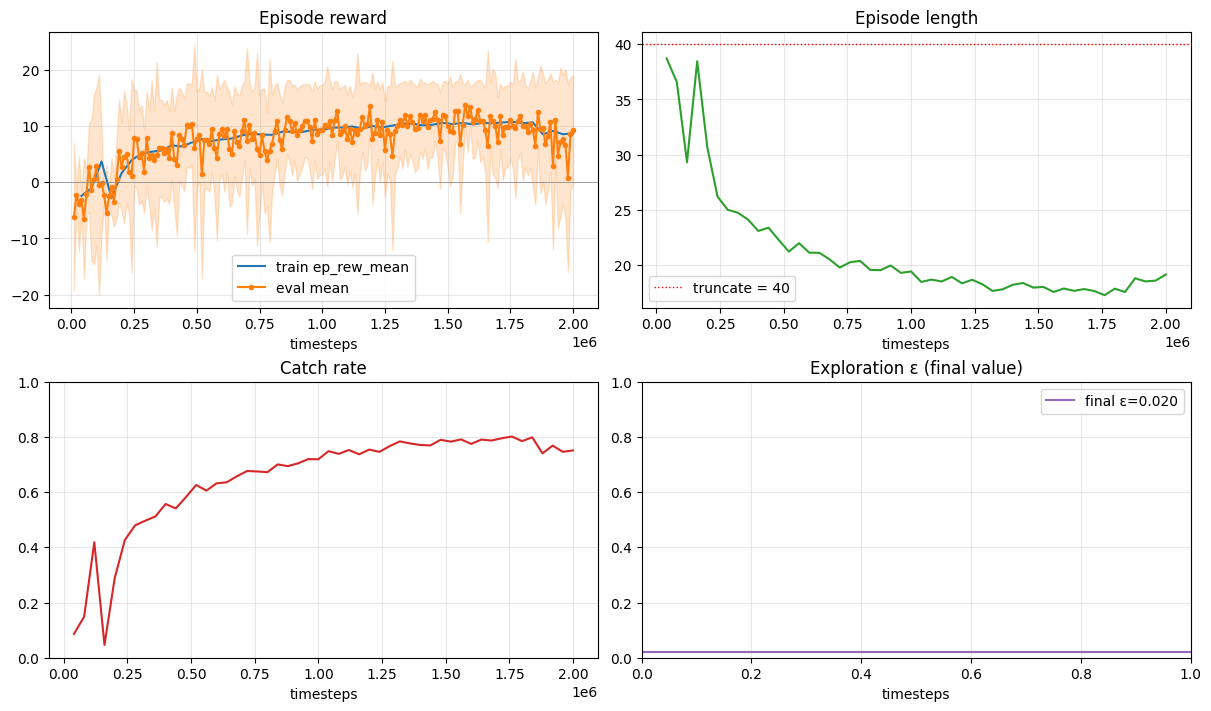

logged 50 metric points


In [10]:
import os
import matplotlib.pyplot as plt

h  = metrics_cb.history
ts = np.asarray(h['timesteps'])

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

# Episode reward
ax = axes[0, 0]
if len(ts):
    ax.plot(ts, h['ep_rew_mean'], label='train ep_rew_mean', color='C0')
ev_path = os.path.join(CONFIG['checkpoint_dir'], 'evaluations.npz')
if os.path.exists(ev_path):
    ev = np.load(ev_path)
    ev_mean = ev['results'].mean(axis=1)
    ev_std  = ev['results'].std(axis=1)
    ax.plot(ev['timesteps'], ev_mean, label='eval mean', color='C1', marker='o', markersize=3)
    ax.fill_between(ev['timesteps'], ev_mean - ev_std, ev_mean + ev_std, alpha=0.2, color='C1')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_title('Episode reward'); ax.set_xlabel('timesteps'); ax.legend(); ax.grid(alpha=0.3)

# Episode length
ax = axes[0, 1]
if len(ts):
    ax.plot(ts, h['ep_len_mean'], color='C2')
ax.axhline(CONFIG['max_episode_steps'], color='red', linestyle=':', linewidth=1,
           label=f'truncate = {CONFIG["max_episode_steps"]}')
ax.set_title('Episode length'); ax.set_xlabel('timesteps'); ax.legend(); ax.grid(alpha=0.3)

# Catch rate
ax = axes[1, 0]
if len(ts):
    ax.plot(ts, h['catch_rate'], color='C3')
ax.set_ylim(0, 1); ax.set_title('Catch rate'); ax.set_xlabel('timesteps'); ax.grid(alpha=0.3)

# Exploration epsilon (from model internals)
ax = axes[1, 1]
if hasattr(model, 'exploration_rate'):
    ax.axhline(model.exploration_rate, color='C4', label=f'final ε={model.exploration_rate:.3f}')
ax.set_title('Exploration ε (final value)'); ax.set_xlabel('timesteps')
ax.legend(); ax.grid(alpha=0.3)

plt.show()
print(f'logged {len(ts)} metric points')

## Q-value heatmap

AttributeError: 'FigureCanvasAgg' object has no attribute 'tostring_rgb'

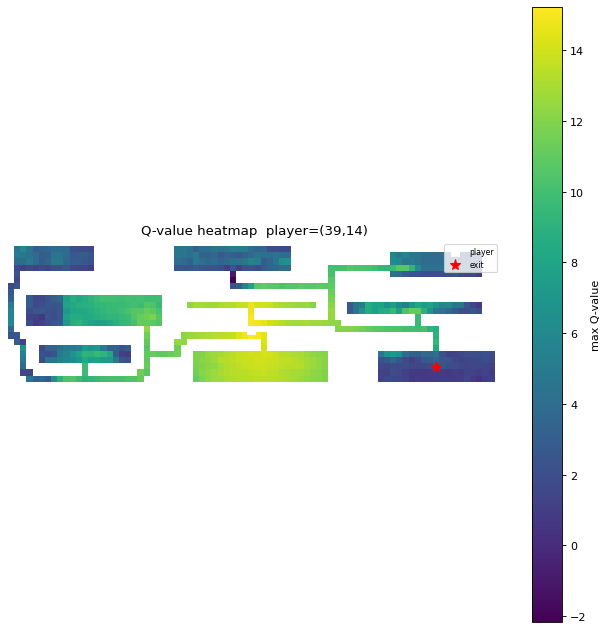

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt


def render_q_heatmap(model, topology, player_pos, player_angle=0.0, figsize=(8, 8), dpi=80):
    """Return (H, W, 3) uint8 array with Q-value heatmap and best-action arrows."""
    device = next(model.policy.parameters()).device
    walkable  = topology.walkable_points()
    memory    = PursuerMemory()
    scent_map = chase_scent_map(topology, player_pos)

    obs_list = []
    for px, py in walkable:
        obs = build_observation(
            topology=topology,
            pursuer_pos=(px, py),
            pursuer_hp_frac=1.0,
            pursuer_stamina_frac=1.0,
            memory=memory,
            player_pos=player_pos,
            player_angle_rad=player_angle,
            cone_mask=None,
            scent_map=scent_map,
        )
        obs_list.append(obs)

    obs_t = torch.tensor(np.stack(obs_list), dtype=torch.float32, device=device)
    with torch.no_grad():
        quantiles = model.policy.quantile_net(obs_t)  # (N, n_actions, n_q)
        q_values  = quantiles.mean(dim=-1).cpu().numpy()

    max_q  = q_values.max(axis=1)
    best_a = q_values.argmax(axis=1)

    q_grid = np.full((topology.height, topology.width), float('nan'))
    for i, (px, py) in enumerate(walkable):
        q_grid[py, px] = max_q[i]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    vmin = np.nanmin(q_grid) if not np.all(np.isnan(q_grid)) else 0
    vmax = np.nanmax(q_grid) if not np.all(np.isnan(q_grid)) else 1
    im = ax.imshow(q_grid, cmap='viridis', vmin=vmin, vmax=vmax,
                   origin='upper', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='max Q-value')

    arrow_kw = dict(head_width=0.3, head_length=0.2, fc='white', ec='white', alpha=0.7)
    for i, (px, py) in enumerate(walkable):
        dx, dy = ACTION_VECTORS.get(best_a[i], (0, 0))
        if dx != 0 or dy != 0:
            ax.arrow(px, py, dx * 0.4, dy * 0.4, **arrow_kw)

    ax.plot(player_pos[0], player_pos[1], 'ws', markersize=8, label='player')
    ex, ey = topology.exit_point
    ax.plot(ex, ey, 'r*', markersize=10, label='exit')
    ax.set_title(f'Q-value heatmap  player=({player_pos[0]},{player_pos[1]})')
    ax.legend(loc='upper right', fontsize=7)
    ax.axis('off')
    plt.tight_layout()

    fig.canvas.draw()
    w_px, h_px = fig.canvas.get_width_height()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8).reshape(h_px, w_px, 3)
    plt.close(fig)
    return img  # (H, W, 3)


_eval_env_inner = eval_vec.envs[0]
_eval_env_inner.reset(seed=0)
heatmap = render_q_heatmap(model, _eval_env_inner.topology, _eval_env_inner.player_pos)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(heatmap)
ax.axis('off')
plt.tight_layout()
plt.show()

## Evaluation vs baseline

In [12]:
class BaselinePolicy:
    """
    Greedy Dijkstra chase — same algorithm as Go's dijkstraCardinal.
    Has perfect information (reads player_pos directly). Acts as skill floor:
    the RL policy must outperform it on ambush/stealth metrics.
    """

    def __init__(self, env):
        self._env = env

    def predict(self, obs, deterministic=True):
        env = self._env
        scent = chase_scent_map(env.topology, env.player_pos)
        ox, oy = env.pursuer_pos
        center_val = int(scent[oy, ox])
        candidates, min_val = [], center_val
        for action, (dx, dy) in ACTION_VECTORS.items():
            if action == ACTION_WAIT:
                continue
            nx, ny = ox + dx, oy + dy
            if not env.topology.is_walkable(nx, ny):
                continue
            v = int(scent[ny, nx])
            if v < min_val:
                min_val, candidates = v, [(action, nx, ny)]
            elif v == min_val:
                candidates.append((action, nx, ny))
        if not candidates:
            return ACTION_WAIT, None
        px, py = env.player_pos
        action, _, _ = min(candidates, key=lambda c: (abs(c[1]-px)+abs(c[2]-py), c[0]))
        return action, None


def rollout(policy_name, policy, eval_env, n_episodes=30, seed_base=1000):
    returns, lengths, in_cone_ratios = [], [], []
    catches, total_hits, ambush_hits = 0, 0, 0
    first_hit_turns = []
    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=seed_base + ep)
        ep_ret, ep_steps, ep_in_cone = 0.0, 0, 0
        ep_hits, ep_ambush, first_hit = 0, 0, None
        done, info = False, {}
        while not done:
            action, _ = policy.predict(obs, deterministic=True)
            obs, r, term, trunc, info = eval_env.step(int(action))
            ep_ret += r; ep_steps += 1
            if info.get('in_cone'): ep_in_cone += 1
            if info.get('pursuer_hit'):
                ep_hits += 1
                if first_hit is None: first_hit = ep_steps
            if info.get('ambush_hit'): ep_ambush += 1
            done = term or trunc
        returns.append(ep_ret); lengths.append(ep_steps)
        in_cone_ratios.append(ep_in_cone / max(ep_steps, 1))
        total_hits += ep_hits; ambush_hits += ep_ambush
        if info.get('caught'): catches += 1
        if first_hit is not None: first_hit_turns.append(first_hit)
    return {
        'policy':          policy_name,
        'avg_return':      float(np.mean(returns)),
        'std_return':      float(np.std(returns)),
        'catch_rate':      catches / n_episodes,
        'avg_in_cone':     float(np.mean(in_cone_ratios)),
        'avg_length':      float(np.mean(lengths)),
        'avg_first_hit':   float(np.mean(first_hit_turns)) if first_hit_turns else float('nan'),
        'total_hits':      total_hits,
        'ambush_ratio':    ambush_hits / max(total_hits, 1),
    }


eval_env = PursuerEnv(
    CONFIG['topologies_dir'], scripted_player_policy,
    max_episode_steps=CONFIG['max_episode_steps'], seed=999,
)

results = [
    rollout('QR-DQN',             model,                 eval_env, n_episodes=30),
    rollout('Baseline (Dijkstra)', BaselinePolicy(eval_env), eval_env, n_episodes=30),
]

hdr = f"{'policy':<26} {'return':>14} {'catch':>7} {'in_cone':>9} {'len':>6} {'1st_hit':>8} {'hits':>6} {'ambush':>8}"
print(hdr)
print('-' * len(hdr))
for r in results:
    fh = f"{r['avg_first_hit']:>8.1f}" if r['avg_first_hit'] == r['avg_first_hit'] else f"{'nan':>8}"
    print(
        f"{r['policy']:<26} {r['avg_return']:>7.2f} ± {r['std_return']:>4.2f}"
        f" {r['catch_rate']:>7.1%} {r['avg_in_cone']:>9.3f} {r['avg_length']:>6.1f}"
        f" {fh} {r['total_hits']:>6d} {r['ambush_ratio']:>8.1%}"
    )

policy                             return   catch   in_cone    len  1st_hit   hits   ambush
-------------------------------------------------------------------------------------------
QR-DQN                        8.70 ± 12.23   80.0%     0.177   14.6     10.7     48    62.5%
Baseline (Dijkstra)          11.04 ± 10.57   90.0%     0.191   12.7     10.7     54    63.0%


## ONNX export + parity check

In [13]:
import onnxruntime as ort


class _QRDQNActor(nn.Module):
    """Averages quantile estimates → (batch, n_actions) logits for Go argmax."""

    def __init__(self, q_net):
        super().__init__()
        self.q_net = q_net

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.q_net(obs).mean(dim=-1)  # (B, n_actions, n_q) → (B, n_actions)


actor = _QRDQNActor(model.policy.quantile_net).eval()
dummy = torch.zeros(1, OBSERVATION_SIZE, dtype=torch.float32)

with torch.no_grad():
    torch.onnx.export(
        actor, dummy, CONFIG['model_out'],
        input_names=['input'], output_names=['logits'],
        opset_version=17, dynamic_axes=None,
    )
print('exported', CONFIG['model_out'])

# Parity check
sess = ort.InferenceSession(CONFIG['model_out'])
rng = np.random.default_rng(0)
max_diff = 0.0
from rl.pursuer_env import OBSERVATION_GRID_FLOATS, OBSERVATION_SCALARS
for _ in range(1000):
    # grid [0,1] (binary/normalized), scalars [-1,1] (signed features).
    grid_in   = rng.uniform(0.0, 1.0, size=(1, OBSERVATION_GRID_FLOATS)).astype(np.float32)
    scalar_in = rng.uniform(-1.0, 1.0, size=(1, OBSERVATION_SCALARS)).astype(np.float32)
    sample    = np.concatenate([grid_in, scalar_in], axis=1)
    
    with torch.no_grad():
        py_out = actor(torch.from_numpy(sample)).numpy()
    ort_out = sess.run(['logits'], {'input': sample})[0]
    max_diff = max(max_diff, float(np.max(np.abs(py_out - ort_out))))

print(f'max |PyTorch - ONNX| = {max_diff:.2e}')
assert max_diff < 1e-4, 'ONNX parity check failed'

W0420 04:52:50.542000 47852 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0420 04:52:50.879000 47852 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0420 04:52:50.880000 47852 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0420 04:52:50.880000 47852 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `_QRDQNActor([...]` with `torch.export.export(..., strict=False)`...


/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/stepan/Documents/Study/21/Rogue/.venv/lib/python3.14/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/Users/stepan/Documents/Study/21/Rogue/.venv/lib/python3.14/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api


[torch.onnx] Obtain model graph for `_QRDQNActor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 6 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
exported models/pursuer.onnx


ModuleNotFoundError: No module named 'rl'

In [14]:
# === Generalization rollout ===
from rl.pursuer_env import PursuerEnv
from rl.scripted_player import scripted_player_policy

PROFILES = ['stone', 'training_dummy', 'default', 'aggressive', 'cautious', 'timid']
N_EP = 30

def run_rollout(policy_fn, profile: str, n_ep: int = N_EP) -> dict:
    env = PursuerEnv(
        CONFIG['topologies_dir'], scripted_player_policy,
        max_episode_steps=CONFIG['max_episode_steps'],
        fixed_profile=profile, distractor_prob=0.0,
        randomize_player_profile=False, seed=999,
    )
    caught = 0
    rewards = []
    for ep in range(n_ep):
        obs, _ = env.reset(seed=10_000 + ep)
        ep_r, done = 0.0, False
        while not done:
            action, _ = policy_fn(obs, env)
            obs, r, term, trunc, info = env.step(action)
            ep_r += r
            done = term or trunc
        rewards.append(ep_r)
        if info.get('caught'):
            caught += 1
    return {
        'profile': profile,
        'catch_rate': caught / n_ep,
        'ep_rew_mean': float(np.mean(rewards)),
    }

def qrdqn_policy(obs, env):
    a, _ = model.predict(obs, deterministic=True)
    return int(a), None

print(f"{'profile':<16} {'catch':>8} {'rew_mean':>10}")
for p in PROFILES:
    r = run_rollout(qrdqn_policy, p)
    print(f"{r['profile']:<16} {r['catch_rate']:>7.1%} {r['ep_rew_mean']:>10.2f}")

ModuleNotFoundError: No module named 'rl'